<a href="https://colab.research.google.com/github/alan-ajay/Condensed-Matter-Physics/blob/main/CMP_assignment_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tight-Binding Model Analysis


---

## 1. Two-Leg Ladder: Basic Hamiltonian
The simplest case involves hopping $t$ along the legs and $t'$ between the rungs.

### Hamiltonian and Dispersion
In the basis of $(\psi_{top}, \psi_{bottom})$, the $k$-space Hamiltonian is:
$$\mathcal{H}(k) = \begin{pmatrix} -2t \cos(k) & -t' \\ -t' & -2t \cos(k) \end{pmatrix}$$

The resulting energy bands are:
$$E_{\pm}(k) = -2t \cos(k) \pm t'$$

### Insulator-to-Metal Transition
* **Insulator**: Occurs when a global energy gap exists between the bonding and anti-bonding bands.
* **Transition Point**: The gap closes exactly when $t/t' = 0.5$.
* **Metal**: For $t/t' > 0.5$, the bands overlap, creating a metallic state.

---



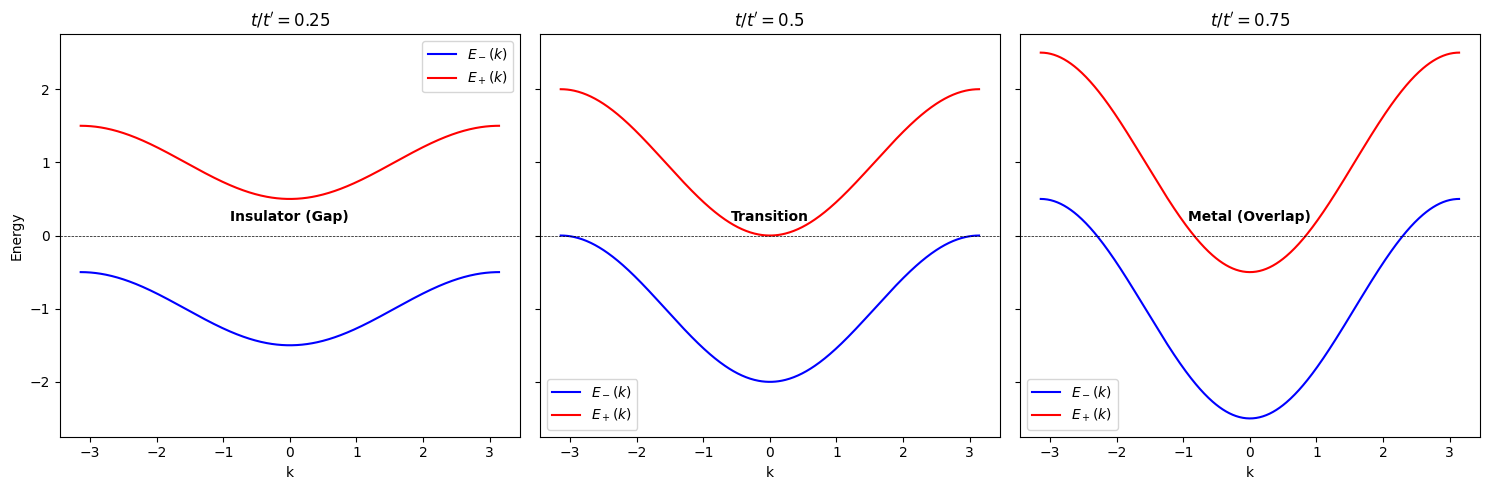

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
k = np.linspace(-np.pi, np.pi, 500)
t_prime = 1.0
t_values = [0.25, 0.5, 0.75]  # t/t' = 0.25, 0.5, 0.75

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

for i, t in enumerate(t_values):
    ratio = t / t_prime
    E_minus = -2 * t * np.cos(k) - t_prime
    E_plus = -2 * t * np.cos(k) + t_prime

    axes[i].plot(k, E_minus, label=r'$E_-(k)$', color='blue')
    axes[i].plot(k, E_plus, label=r'$E_+(k)$', color='red')

    # Fill between bands if they overlap or indicate gap
    max_lower = np.max(E_minus)
    min_upper = np.min(E_plus)

    axes[i].set_title(f'$t/t\' = {ratio}$')
    axes[i].set_xlabel('k')
    if i == 0:
        axes[i].set_ylabel('Energy')
    axes[i].axhline(0, color='black', linewidth=0.5, linestyle='--')
    axes[i].legend()

    # Text for Insulator/Metal
    if ratio < 0.5:
        axes[i].text(0, 0.2, 'Insulator (Gap)', ha='center', fontweight='bold')
    elif ratio == 0.5:
        axes[i].text(0, 0.2, 'Transition', ha='center', fontweight='bold')
    else:
        axes[i].text(0, 0.2, 'Metal (Overlap)', ha='center', fontweight='bold')

plt.tight_layout()
# plt.savefig('band_structure_transition.png')

## 2. Effects of Diagonal Hopping ($t''$)
Adding diagonal terms $t''$ modifies the inter-leg coupling into a $k$-dependent function.

### Case (a): Single Diagonal Hopping
* **Dispersion**: $E_{\pm}(k) = -2t \cos(k) \pm \sqrt{t'^2 + t''^2 + 2t't'' \cos(k)}$.
* **Impact**: $t''$ breaks the symmetry between the two bands and shifts the specific $k$-points where the gap is smallest.





<>:34: SyntaxWarning: invalid escape sequence '\p'
<>:34: SyntaxWarning: invalid escape sequence '\p'
<>:34: SyntaxWarning: invalid escape sequence '\p'
<>:34: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_1844/2679223647.py:34: SyntaxWarning: invalid escape sequence '\p'
  axes[i].set_xticklabels(['$-\pi$', '0', '$\pi$'])
/tmp/ipykernel_1844/2679223647.py:34: SyntaxWarning: invalid escape sequence '\p'
  axes[i].set_xticklabels(['$-\pi$', '0', '$\pi$'])


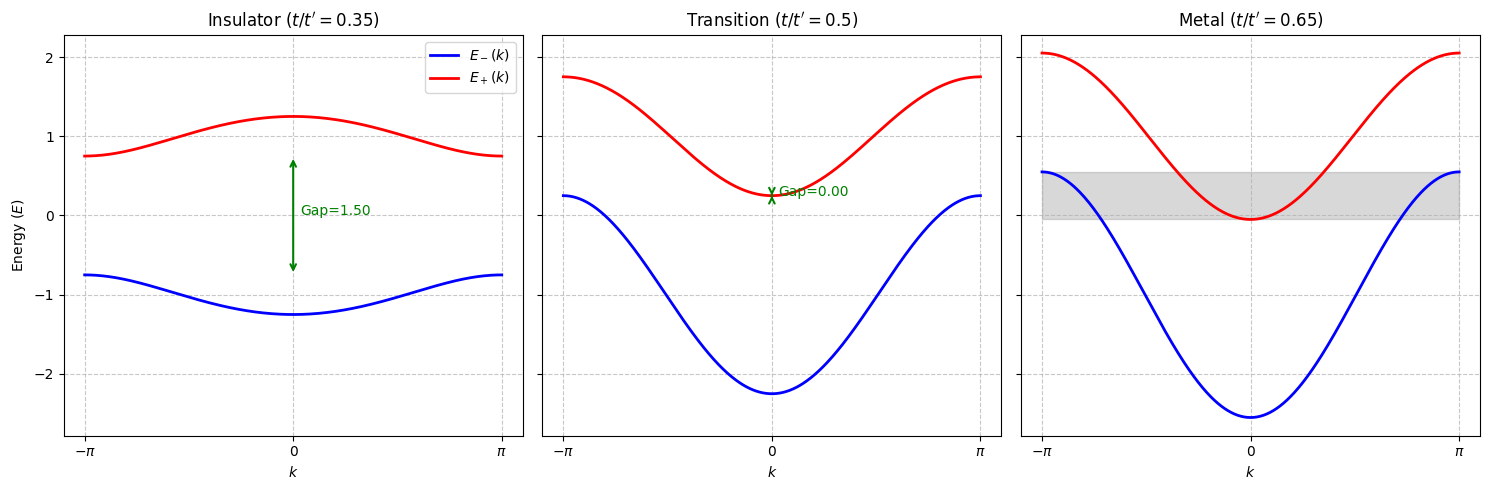

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def get_bands(k, t, tp, tpp):
    # Hamiltonian matrix:
    # H_11 = H_22 = -2t cos(k)
    # H_12 = -tp - tpp * exp(-ik)
    # H_21 = -tp - tpp * exp(ik)
    # Eigenvalues E = -2t cos(k) +/- sqrt(tp^2 + tpp^2 + 2*tp*tpp*cos(k))
    diag = -2 * t * np.cos(k)
    off_diag_mag = np.sqrt(tp**2 + tpp**2 + 2 * tp * tpp * np.cos(k))
    return diag - off_diag_mag, diag + off_diag_mag

# Parameters
tp = 1.0
tpp = 0.25
t_values = [0, 0.5, 0.65] # Insulator, Transition, Metal
labels = ['Insulator ($t/t\' = 0.35$)', 'Transition ($t/t\' = 0.5$)', 'Metal ($t/t\' = 0.65$)']

k = np.linspace(-np.pi, np.pi, 500)

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

for i, t_val in enumerate(t_values):
    t = t_val * tp
    E_minus, E_plus = get_bands(k, t, tp, tpp)

    axes[i].plot(k, E_minus, label='$E_-(k)$', color='blue', linewidth=2)
    axes[i].plot(k, E_plus, label='$E_+(k)$', color='red', linewidth=2)

    axes[i].set_title(labels[i])
    axes[i].set_xlabel('$k$')
    axes[i].set_xticks([-np.pi, 0, np.pi])
    axes[i].set_xticklabels(['$-\pi$', '0', '$\pi$'])
    axes[i].grid(True, linestyle='--', alpha=0.7)

    if i == 0:
        axes[i].set_ylabel('Energy ($E$)')

    # Indicate gap or overlap
    max_low = np.max(E_minus)
    min_high = np.min(E_plus)
    if min_high > max_low:
        # Draw gap indicator
        axes[i].annotate('', xy=(0, max_low), xytext=(0, min_high),
                         arrowprops=dict(arrowstyle='<->', color='green', lw=1.5))
        axes[i].text(0.1, (max_low + min_high)/2, f'Gap={min_high-max_low:.2f}', color='green')
    elif np.isclose(min_high, max_low, atol=1e-3):
        axes[i].scatter([0, np.pi, -np.pi], [min_high, max_low, max_low], color='black', zorder=5)
    else:
        # Highlight overlap
        axes[i].fill_between(k, min_high, max_low, color='gray', alpha=0.3, label='Overlap')

axes[0].legend()
plt.tight_layout()

### Case (b): Symmetric (Crossed) Diagonal Hopping
* **Dispersion**: $E_{\pm}(k) = -2t \cos(k) \pm |t' + 2t'' \cos(k)|$.
* **Impact**: This configuration allows for the creation of **flat bands** (infinite effective mass) if parameters are tuned such that the $\cos(k)$ terms cancel out.

---

<>:40: SyntaxWarning: invalid escape sequence '\p'
<>:40: SyntaxWarning: invalid escape sequence '\p'
<>:40: SyntaxWarning: invalid escape sequence '\p'
<>:40: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_1844/3336359450.py:40: SyntaxWarning: invalid escape sequence '\p'
  axes[i].set_xticklabels(['$-\pi$', '0', '$\pi$'])
/tmp/ipykernel_1844/3336359450.py:40: SyntaxWarning: invalid escape sequence '\p'
  axes[i].set_xticklabels(['$-\pi$', '0', '$\pi$'])


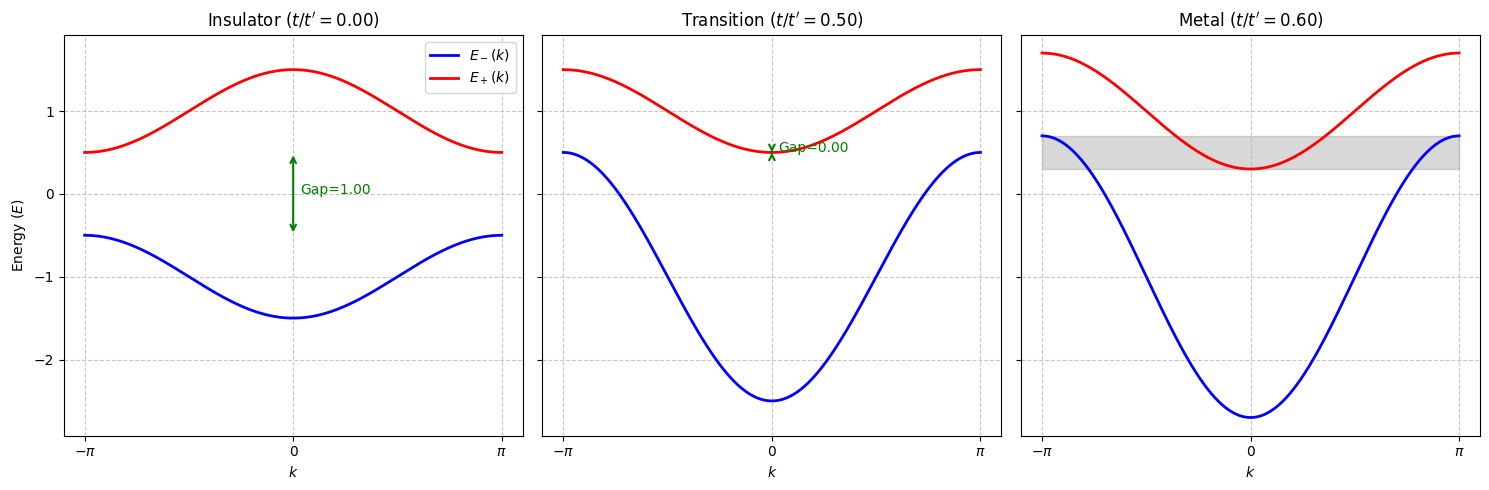

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def get_bands_symmetric(k, t, tp, tpp):
    # Hamiltonian matrix for case (b):
    # H_11 = H_22 = -2t cos(k)
    # H_12 = H_21 = -tp - 2*tpp * cos(k)
    # Eigenvalues E = -2t cos(k) +/- |tp + 2*tpp * cos(k)|
    diag = -2 * t * np.cos(k)
    off_diag = tp + 2 * tpp * np.cos(k)
    return diag - np.abs(off_diag), diag + np.abs(off_diag)

# Parameters
tp = 1.0
tpp = 0.25  # Symmetric diagonal hopping
# Transition point for symmetric case can vary;
# At k=pi, gap closes when |-2t(-1) - (tp + 2tpp(-1))| = |-2t(-1) + (tp + 2tpp(-1))|
# which simplifies to 4t = 2|tp - 2tpp| => t = |tp - 2tpp|/2
t_crit = np.abs(tp - 2 * tpp) / 2.0

t_values = [0, 0.5, 0.6]
labels = [f'Insulator ($t/t\' = {t_values[0]:.2f}$)',
          f'Transition ($t/t\' = {t_values[1]:.2f}$)',
          f'Metal ($t/t\' = {t_values[2]:.2f}$)']

k = np.linspace(-np.pi, np.pi, 500)

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

for i, t_val in enumerate(t_values):
    t = t_val * tp
    E_minus, E_plus = get_bands_symmetric(k, t, tp, tpp)

    axes[i].plot(k, E_minus, label='$E_-(k)$', color='blue', linewidth=2)
    axes[i].plot(k, E_plus, label='$E_+(k)$', color='red', linewidth=2)

    axes[i].set_title(labels[i])
    axes[i].set_xlabel('$k$')
    axes[i].set_xticks([-np.pi, 0, np.pi])
    axes[i].set_xticklabels(['$-\pi$', '0', '$\pi$'])
    axes[i].grid(True, linestyle='--', alpha=0.7)

    if i == 0:
        axes[i].set_ylabel('Energy ($E$)')

    max_low = np.max(E_minus)
    min_high = np.min(E_plus)

    if min_high > max_low:
        axes[i].annotate('', xy=(0, max_low), xytext=(0, min_high),
                         arrowprops=dict(arrowstyle='<->', color='green', lw=1.5))
        axes[i].text(0.1, (max_low + min_high)/2, f'Gap={min_high-max_low:.2f}', color='green')
    elif np.isclose(min_high, max_low, atol=1e-2):
        # In symmetric case, touching usually happens at pi (or 0 depending on tpp)
        axes[i].scatter([np.pi, -np.pi], [E_plus[-1], E_plus[0]], color='black', zorder=5, label='Touching Point')
    else:
        axes[i].fill_between(k, min_high, max_low, color='gray', alpha=0.3, label='Overlap')

axes[0].legend()
plt.tight_layout()
plt.savefig('symmetric_ladder_bands.png')

## 3. 2D Square Lattice Analysis
The model is extended to a 2D square lattice with nearest-neighbor hopping $t = -2$ eV.

### Standard Square Lattice (3a)
* **Dispersion**: $E(k_x, k_y) = 4(\cos(k_x) + \cos(k_y))$.
* **Fermi Curves**:
    * **0.5e**: Circular electron-like pockets.
    * **1.0e (Half-filling)**: A perfect diamond shape exhibiting "nesting".
    * **2.0e**: Fully filled BZ (Insulator).



### Square Lattice with Next-Nearest Neighbor Hopping (3b)
Adding $t''$ (diagonal hopping) of $\pm 1$ eV:
* **Dispersion**: $E(k_x, k_y) = -2t(\cos k_x + \cos k_y) - 4t'' \cos k_x \cos k_y$.
* **Symmetry Breaking**: The diagonal hopping destroys the particle-hole symmetry, warping the half-filled diamond into either "hole-like" or "electron-like" trajectories.

---

<>:47: SyntaxWarning: invalid escape sequence '\p'
<>:47: SyntaxWarning: invalid escape sequence '\p'
<>:48: SyntaxWarning: invalid escape sequence '\p'
<>:48: SyntaxWarning: invalid escape sequence '\p'
<>:47: SyntaxWarning: invalid escape sequence '\p'
<>:47: SyntaxWarning: invalid escape sequence '\p'
<>:48: SyntaxWarning: invalid escape sequence '\p'
<>:48: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_1844/2596313717.py:47: SyntaxWarning: invalid escape sequence '\p'
  plt.xticks([-np.pi, 0, np.pi], ['$-\pi$', '0', '$\pi$'])
/tmp/ipykernel_1844/2596313717.py:47: SyntaxWarning: invalid escape sequence '\p'
  plt.xticks([-np.pi, 0, np.pi], ['$-\pi$', '0', '$\pi$'])
/tmp/ipykernel_1844/2596313717.py:48: SyntaxWarning: invalid escape sequence '\p'
  plt.yticks([-np.pi, 0, np.pi], ['$-\pi$', '0', '$\pi$'])
/tmp/ipykernel_1844/2596313717.py:48: SyntaxWarning: invalid escape sequence '\p'
  plt.yticks([-np.pi, 0, np.pi], ['$-\pi$', '0', '$\pi$'])


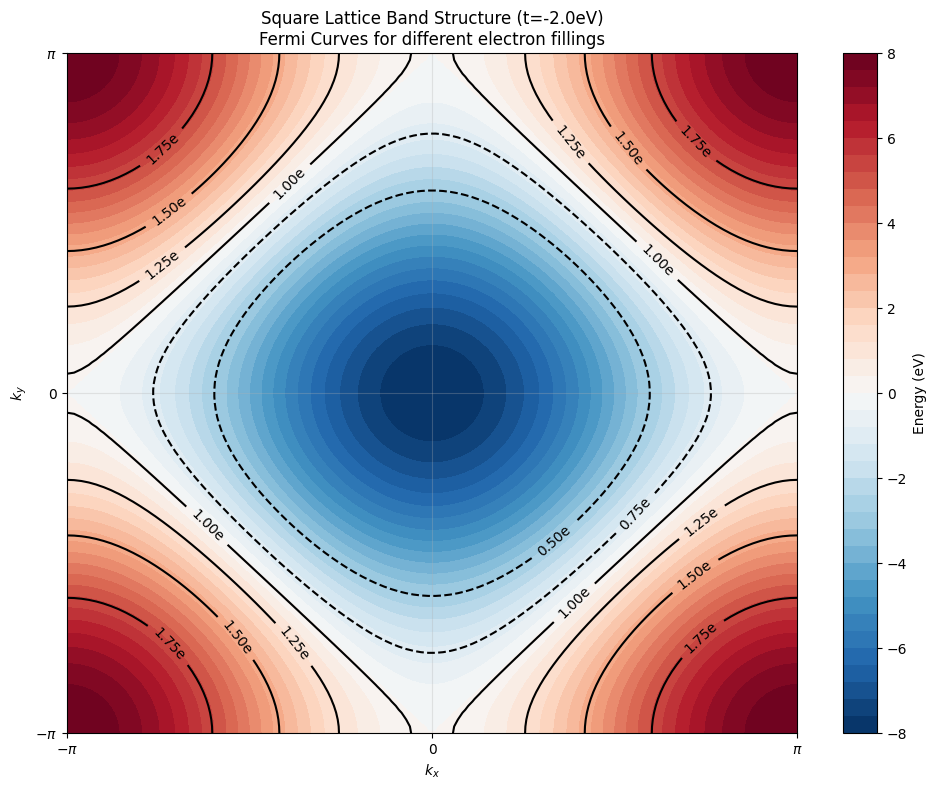

In [31]:
import numpy as np
import matplotlib.pyplot as plt

def solve_square_lattice():
    # Parameters
    t = -2.0  # eV
    L = 100   # Grid size for BZ
    kx = np.linspace(-np.pi, np.pi, L)
    ky = np.linspace(-np.pi, np.pi, L)
    KX, KY = np.meshgrid(kx, ky)

    # Dispersion for square lattice: E = -2t(cos(kx) + cos(ky))
    # Note: problem says t = -2eV, so we use that.
    E = 2 * t * (np.cos(KX) + np.cos(KY))

    # Flatten and sort to find Fermi levels
    energies_flat = E.flatten()
    energies_sorted = np.sort(energies_flat)

    # Electron counts per unit cell (spin degeneracy = 2)
    # Filling fraction f = n / 2.
    # Indices for the sorted list: n_electrons / 2 * total_points
    filling_counts = np.arange(0.5, 2.25, 0.25)
    fermi_levels = []

    total_points = len(energies_sorted)
    for n in filling_counts:
        # Index calculation: fraction of the states filled
        # n electrons per unit cell out of 2 possible (spin)
        idx = int((n / 2.0) * (total_points - 1))
        fermi_levels.append(energies_sorted[idx])

    # Plotting
    plt.figure(figsize=(10, 8))
    contour = plt.contourf(KX, KY, E, levels=50, cmap='RdBu_r')
    plt.colorbar(contour, label='Energy (eV)')

    # Plot Fermi curves
    for i, ef in enumerate(fermi_levels):
        cs = plt.contour(KX, KY, E, levels=[ef], colors=['black'], linewidths=1.5)
        # Label roughly near the curve
        plt.clabel(cs, inline=True, fmt={ef: f'{filling_counts[i]:.2f}e'}, fontsize=10)

    plt.title(f'Square Lattice Band Structure (t={t}eV)\nFermi Curves for different electron fillings')
    plt.xlabel('$k_x$')
    plt.ylabel('$k_y$')
    plt.xticks([-np.pi, 0, np.pi], ['$-\pi$', '0', '$\pi$'])
    plt.yticks([-np.pi, 0, np.pi], ['$-\pi$', '0', '$\pi$'])
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('square_lattice_fermi.png')

solve_square_lattice()

<>:41: SyntaxWarning: invalid escape sequence '\p'
<>:41: SyntaxWarning: invalid escape sequence '\p'
<>:42: SyntaxWarning: invalid escape sequence '\p'
<>:42: SyntaxWarning: invalid escape sequence '\p'
<>:41: SyntaxWarning: invalid escape sequence '\p'
<>:41: SyntaxWarning: invalid escape sequence '\p'
<>:42: SyntaxWarning: invalid escape sequence '\p'
<>:42: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_1844/295721325.py:41: SyntaxWarning: invalid escape sequence '\p'
  plt.xticks([-np.pi, 0, np.pi], ['$-\pi$', '0', '$\pi$'])
/tmp/ipykernel_1844/295721325.py:41: SyntaxWarning: invalid escape sequence '\p'
  plt.xticks([-np.pi, 0, np.pi], ['$-\pi$', '0', '$\pi$'])
/tmp/ipykernel_1844/295721325.py:42: SyntaxWarning: invalid escape sequence '\p'
  plt.yticks([-np.pi, 0, np.pi], ['$-\pi$', '0', '$\pi$'])
/tmp/ipykernel_1844/295721325.py:42: SyntaxWarning: invalid escape sequence '\p'
  plt.yticks([-np.pi, 0, np.pi], ['$-\pi$', '0', '$\pi$'])


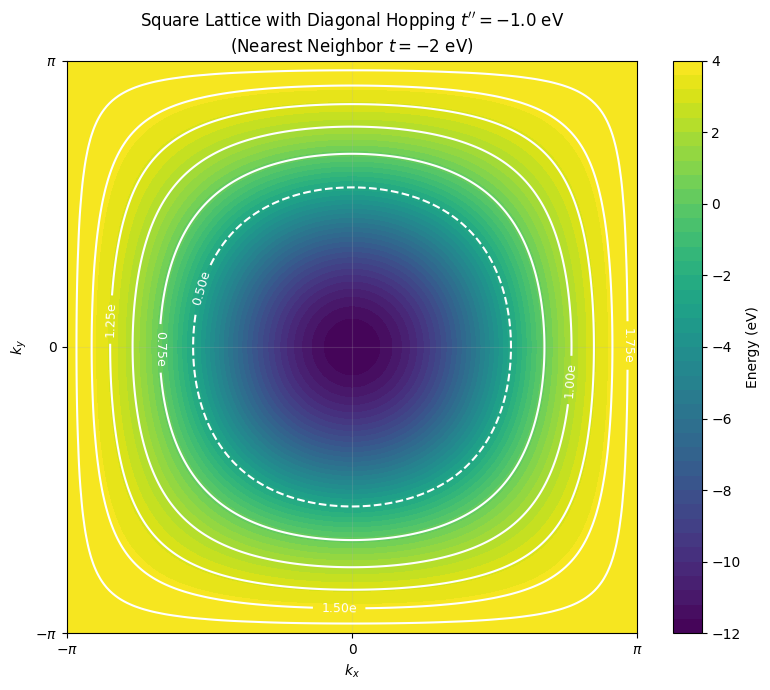

In [32]:
import numpy as np
import matplotlib.pyplot as plt

def solve_square_lattice_with_diagonal(t_diag):
    # Parameters
    t = -2.0  # eV (Nearest Neighbor)
    L = 200   # Grid size for BZ
    kx = np.linspace(-np.pi, np.pi, L)
    ky = np.linspace(-np.pi, np.pi, L)
    KX, KY = np.meshgrid(kx, ky)

    # Nearest neighbor term: -2t(cos(kx) + cos(ky))
    # Diagonal neighbor term: -2t_diag * (cos(kx+ky) + cos(kx-ky))
    # Which simplifies to: -4t_diag * cos(kx) * cos(ky)
    # Total E = -2t(cos(kx) + cos(ky)) - 4t_diag * cos(kx) * cos(ky)
    E = 2 * t * (np.cos(KX) + np.cos(KY)) + 4 * t_diag * (np.cos(KX) * np.cos(KY))

    # Sort energies
    energies_sorted = np.sort(E.flatten())
    total_points = len(energies_sorted)

    # Fillings from 0.5e to 2.0e in steps of 0.25e
    filling_counts = np.arange(0.5, 2.25, 0.25)
    fermi_levels = []
    for n in filling_counts:
        idx = int((n / 2.0) * (total_points - 1))
        fermi_levels.append(energies_sorted[idx])

    # Plotting
    plt.figure(figsize=(8, 7))
    contour = plt.contourf(KX, KY, E, levels=50, cmap='viridis')
    plt.colorbar(contour, label='Energy (eV)')

    for i, ef in enumerate(fermi_levels):
        cs = plt.contour(KX, KY, E, levels=[ef], colors=['white'], linewidths=1.5)
        plt.clabel(cs, inline=True, fmt={ef: f'{filling_counts[i]:.2f}e'}, fontsize=9)

    plt.title(f'Square Lattice with Diagonal Hopping $t\'\' = {t_diag}$ eV\n(Nearest Neighbor $t = -2$ eV)')
    plt.xlabel('$k_x$')
    plt.ylabel('$k_y$')
    plt.xticks([-np.pi, 0, np.pi], ['$-\pi$', '0', '$\pi$'])
    plt.yticks([-np.pi, 0, np.pi], ['$-\pi$', '0', '$\pi$'])
    plt.grid(alpha=0.2)
    plt.tight_layout()
    # plt.savefig(f'square_diag_{t_diag}.png')
    plt.show()

# Run for both requested values
solve_square_lattice_with_diagonal(-1.0)


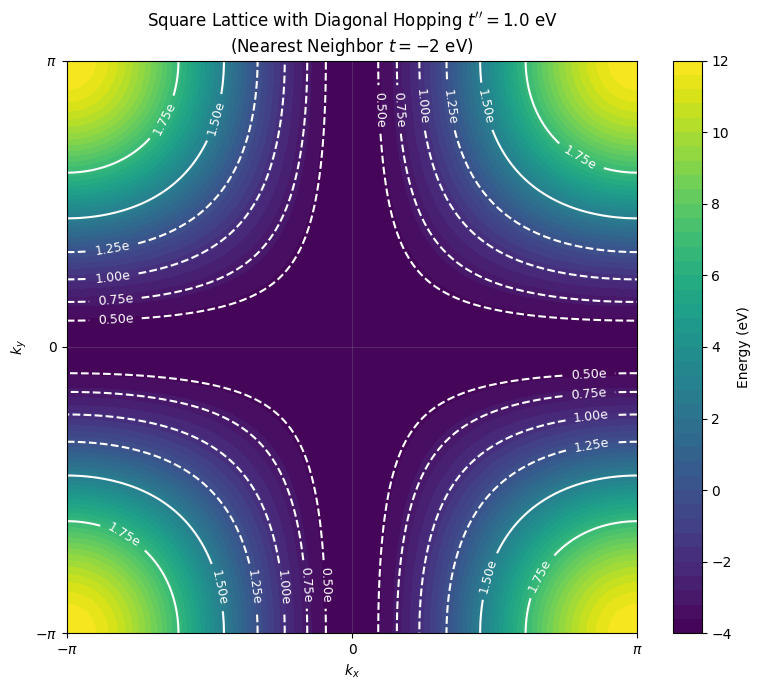

In [33]:
solve_square_lattice_with_diagonal(1.0)